In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.covariance import LedoitWolf
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(1024)
np.random.seed(1024)

Using device: cuda


In [80]:
class PaDiM(nn.Module):
    def __init__(self, n_features=100, device='cpu'):
        super().__init__()

        self.n_features = n_features
        self.device = device

        self.model = self.load_backbone()
        self.model.to(self.device)
        self.model.eval()

        self.features = {}
        self.register_hooks()

        self.threshold = None
        self.mean = None
        self.cov_inv = None
        self.idx = None 

    def load_backbone(self):
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        return model
    
    def save_parameters(self, path):
        torch.save({
            "mean": self.mean,
            "cov_inv": self.cov_inv,
            "idx": self.idx,
        }, path)

    def load_parameters(self, path):
        data = torch.load(path, map_location=self.device)
        self.mean = data["mean"].to(self.device)
        self.cov_inv = data["cov_inv"].to(self.device)
        self.idx = data["idx"]

    def hook(self, idx):
        def fn(module, input, output):
            self.features[idx] = output
        return fn

    def register_hooks(self):
        self.model.layer1[-1].register_forward_hook(self.hook('layer1'))
        self.model.layer2[-1].register_forward_hook(self.hook('layer2'))
        self.model.layer3[-1].register_forward_hook(self.hook('layer3'))

    def embedding_concat(self, x, y):
        B, C1, H1, W1 = x.size()
        _, C2, H2, W2 = y.size()
        s = int(H1 / H2)

        x = F.unfold(x, kernel_size=s, stride=s)
        x = x.view(B, C1, -1, H2, W2)

        z = torch.zeros(B, C1 + C2, x.size(2), H2, W2, device=x.device)
        for i in range(x.size(2)):
            z[:, :, i] = torch.cat((x[:, :, i], y), dim=1)

        z = z.view(B, -1, H2 * W2)
        z = F.fold(z, kernel_size=s, output_size=(H1, W1), stride=s)

        return z

    def extract_features(self, x):
        self.features = {}
        _ = self.model(x)

        feats = [
            self.features['layer1'],
            self.features['layer2'],
            self.features['layer3']
        ]

        x = feats[0]
        for f in feats[1:]:
            x = self.embedding_concat(x, f)

        return x

    def fit(self, dataloader):
        embeddings = []

        for x in dataloader:
            x = x.to(self.device)

            with torch.no_grad():
                feat = self.extract_features(x)
                B, C, H, W = feat.shape

                feat = feat.reshape(B, C, H * W)

                embeddings.append(feat)

        embeddings = torch.cat(embeddings, dim=0)  # (N, C, HW)

        # losowy wybór feature'ów
        C = embeddings.shape[1]
        self.idx = torch.randperm(C)[:self.n_features]
        embeddings = embeddings[:, self.idx, :] # wybranie kanałow (C)

        N, C, HW = embeddings.shape

        self.mean = []
        self.cov_inv = []

        for i in range(HW):
            patch = embeddings[:, :, i].detach().cpu().numpy()

            cov = LedoitWolf().fit(patch)
            self.mean.append(torch.tensor(cov.location_))
            self.cov_inv.append(torch.tensor(cov.precision_))

        self.mean = torch.stack(self.mean).to(self.device)       # (HW, C)
        self.cov_inv = torch.stack(self.cov_inv).to(self.device) # (HW, C, C)

    def predict(self, x):
        x = x.to(self.device)

        with torch.no_grad():
            feat = self.extract_features(x)

        B, C, H, W = feat.shape
        feat = feat[:, self.idx, :, :]
        feat = feat.reshape(B, self.n_features, H * W)

        scores = torch.zeros((B, H, W), device=self.device)

        for b in range(B):
            sample_scores = []

            for i in range(H * W):
                f = feat[b, :, i]
                mean = self.mean[i]
                cov_inv = self.cov_inv[i]

                diff = f - mean
                dist = diff @ cov_inv @ diff.T
                # dist = torch.sqrt(torch.dot(diff, cov_inv @ diff))

                sample_scores.append(dist)

            sample_scores = torch.stack(sample_scores)
            scores.append(sample_scores.reshape(H, W))

        scores = torch.stack(scores)

        scores = F.interpolate(scores.unsqueeze(1), size=x.shape[-2:], mode='bilinear', align_corners=False)
        scores = scores.squeeze(1)
        scores = scores.detach().cpu().numpy()

        for i in range(scores.shape[0]):
            scores[i] = gaussian_filter(scores[i], sigma=4)

        return scores

In [2]:
class PaDiM_v2(nn.Module):
    def __init__(self, n_features=100, device='cpu'):
        super().__init__()

        self.n_features = n_features
        self.device = device

        self.model = self.load_backbone()
        self.model.to(self.device)
        self.model.eval()

        self.features = {}
        self.register_hooks()

        self.threshold = None
        self.mean = None
        self.cov_inv = None
        self.idx = None 

    def load_backbone(self):
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        return model
    
    def save_parameters(self, path):
        torch.save({
            "mean": self.mean,
            "cov_inv": self.cov_inv,
            "idx": self.idx,
        }, path)

    def load_parameters(self, path):
        data = torch.load(path, map_location=self.device)
        self.mean = data["mean"].to(self.device)
        self.cov_inv = data["cov_inv"].to(self.device)
        self.idx = data["idx"]

    def hook(self, idx):
        def fn(module, input, output):
            self.features[idx] = output
        return fn

    def register_hooks(self):
        self.model.layer1.register_forward_hook(self.hook('layer1'))
        self.model.layer2.register_forward_hook(self.hook('layer2'))
        self.model.layer3.register_forward_hook(self.hook('layer3'))

    def extract_features(self, x):
        self.features = {}
        _ = self.model(x)

        f1 = self.features['layer1']
        f2 = self.features['layer2']
        f3 = self.features['layer3']

        f2 = F.interpolate(f2, size=f1.shape[-2:], mode="bilinear", align_corners=False)
        f3 = F.interpolate(f3, size=f1.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([f1, f2, f3], dim=1)

        return x

    def fit(self, dataloader):
        embeddings = []

        for x in dataloader:
            x = x.to(self.device)

            with torch.no_grad():
                feat = self.extract_features(x)
                B, C, H, W = feat.shape

                feat = feat.reshape(B, C, H * W)

                embeddings.append(feat)

        embeddings = torch.cat(embeddings, dim=0)  # (N, C, HW)

        # losowy wybór feature'ów
        C = embeddings.shape[1]
        self.idx = torch.randperm(C)[:self.n_features]
        embeddings = embeddings[:, self.idx, :] # wybranie kanałow (C)

        N, C, HW = embeddings.shape

        self.mean = []
        self.cov_inv = []
        eps = 1e-6

        for i in range(HW):
            patch = embeddings[:, :, i].detach().cpu()  # [N,C]

            mu = patch.mean(dim=0)
            x = patch - mu

            cov = (x.T @ x) / (N - 1)
            cov = cov + eps * torch.eye(C)

            cov_inv = torch.linalg.pinv(cov)

            self.mean.append(mu)
            self.cov_inv.append(cov_inv)

        self.mean = torch.stack(self.mean).to(self.device)
        self.cov_inv = torch.stack(self.cov_inv).to(self.device)

    def predict(self, x):
        x = x.to(self.device)

        with torch.no_grad():
            feat = self.extract_features(x)

        feat = feat[:, self.idx, :, :]  # [B,C,H,W]
        B, C, H, W = feat.shape

        scores = torch.zeros((B, H, W), device=self.device)

        for i in range(H * W):
            h = i // W
            w = i % W

            f = feat[:, :, h, w]  # [B,C]
            mu = self.mean[i]
            cov_inv = self.cov_inv[i]

            diff = f - mu
            left = diff @ cov_inv
            dist = (left * diff).sum(dim=1)

            scores[:, h, w] = dist

        scores = scores.unsqueeze(1)
        scores = F.interpolate(scores, size=x.shape[-2:], mode='bilinear', align_corners=False)
        scores = scores.squeeze(1)

        return scores.detach().cpu().numpy()

In [3]:
class CableTrainDataset(Dataset):
    def __init__(self, train_dir, image_size=256):
        self.files = [os.path.join(train_dir, file) for file in os.listdir(train_dir)]
        self.image_size = image_size

        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor()])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        img = Image.open(img_path).convert("RGB")

        img = self.transform(img)

        return img


class CableTestDataset(Dataset):
    def __init__(self, test_dir, gt_dir, image_size=256):
        self.test_dir = test_dir
        self.gt_dir = gt_dir
        self.img_transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor()
        ])
        
        self.samples = []

        for class_name in os.listdir(test_dir):
                test_class_path = os.path.join(test_dir, class_name)
                gt_class_path = os.path.join(gt_dir, class_name)

                for file_name in os.listdir(test_class_path):
                    test_path = os.path.join(test_class_path, file_name)

                    base_name = os.path.splitext(file_name)[0]
                    gt_file_name = base_name + "_mask.png"
                    gt_path = os.path.join(gt_class_path, gt_file_name)
                    self.samples.append((test_path, gt_path, class_name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        test_path, gt_path, class_name = self.samples[idx]

        image = Image.open(test_path).convert("RGB")

        image = self.img_transform(image)

        if os.path.exists(gt_path):
            mask = Image.open(gt_path)
            mask = np.array(mask, dtype=np.float32)/255
        else:
            mask = np.zeros((1024, 1024))

        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask, class_name

In [4]:
model = PaDiM_v2(n_features=100, device=device)

train_dir = 'cable/train/good'
train_dataset = CableTrainDataset(train_dir)
train_data_loader = DataLoader(train_dataset, batch_size=8, num_workers=4, pin_memory=True)

test_dir = 'cable/test/'
gt_dir = 'cable/ground_truth/'
test_dataset = CableTestDataset(test_dir, gt_dir)
test_data_loader = DataLoader(test_dataset, batch_size=8, num_workers=4, pin_memory=True)

In [ ]:
model.fit(train_data_loader)

model.save_parameters("padim_resnet_100_padim_v2_2.pth")

In [5]:
model.load_parameters("padim_resnet_100_padim_v2.pth")

In [6]:
def remove_small_objects(mask, min_area=1000):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    
    output = np.zeros_like(mask)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            output[labels == i] = 1
            
    return output

def iou(mask1, mask2):
    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)

    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 1.0

    return intersection / union

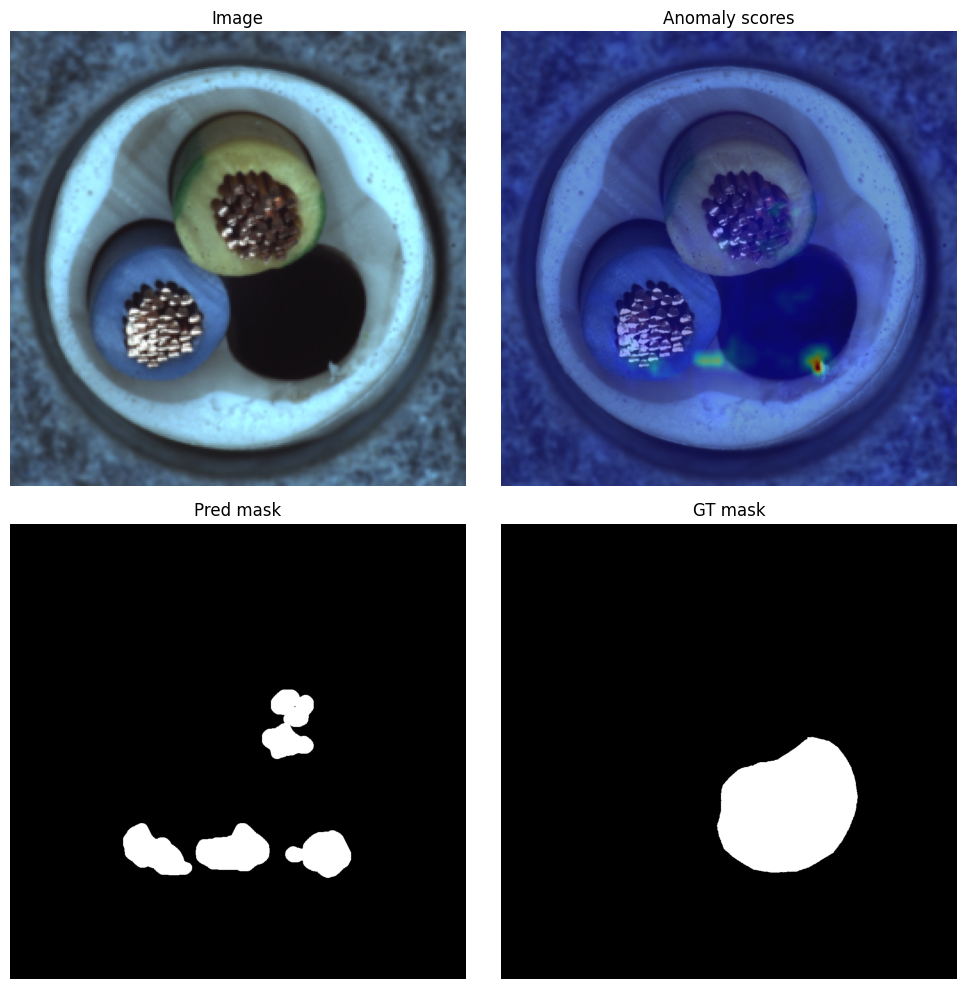

0.13020338152413624


In [39]:
model.eval()
transform = T.Compose([T.Resize((256, 256)),
                       T.ToTensor()])

file = "missing_cable/005"
img_path = f'cable/test/{file}.png'
img0 = Image.open(img_path).convert("RGB")

img = transform(img0).unsqueeze(0)

gt_path = f'cable/ground_truth/{file}_mask.png'
gt = Image.open(gt_path).convert("L")
gt = np.array(gt, dtype=np.float32)/255
# gt = np.zeros((1024, 1024))

scores = model.predict(img).squeeze(0)
scores = cv2.resize(scores, (1024, 1024), interpolation=cv2.INTER_NEAREST)

th = scores.mean() + 2.5 * scores.std()
mask = (scores > th).astype(np.uint8) * 255
mask = gaussian_filter(mask,sigma=4)
kernel = np.ones((7,7), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = remove_small_objects(mask, 5000)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# 1. obraz
axes[0, 0].imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
axes[0, 0].set_title("Image")
axes[0, 0].axis("off")

# 2. scores (heatmapa anomaly)
axes[0, 1].imshow(img0)
axes[0, 1].imshow(scores, cmap="jet", alpha=0.4)
axes[0, 1].set_title("Anomaly scores")
axes[0, 1].axis("off")

# 3. maska predykcji
axes[1, 0].imshow(mask, cmap="gray")
axes[1, 0].set_title("Pred mask")
axes[1, 0].axis("off")

# 4. GT maska
axes[1, 1].imshow(gt, cmap="gray")
axes[1, 1].set_title("GT mask")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()
print(iou(mask,gt))

In [ ]:
from collections import defaultdict

model.eval()

ious_per_class = defaultdict(list)
all_ious = []

with torch.no_grad():
    for imgs, gt, class_names in test_data_loader:
        scores = model.predict(imgs)

        gt = gt.cpu().numpy().astype(np.uint8)

        cleaned_masks = []
        kernel = np.ones((7,7), np.uint8)
        for s in scores:
            s = cv2.resize(s, (1024, 1024), interpolation=cv2.INTER_NEAREST)
            th = s.mean() + 2.5 * s.std()
            m = (s > th).astype(np.uint8) * 255

            m = gaussian_filter(m, sigma=4)

            m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel)
            # m = cv2.resize(m, (1024, 1024), interpolation=cv2.INTER_NEAREST)
            m = remove_small_objects(m, 5000)

            m_crop = np.zeros_like(m)
            m_crop[150:850, 150:850] = m[150:850, 150:850]
            m_crop

            cleaned_masks.append(m_crop)

        for p, m, cls in zip(cleaned_masks, gt, class_names):
            score = iou(p, m)
            ious_per_class[cls].append(score)
            all_ious.append(score)

for cls, scores in ious_per_class.items():
    print(f"{cls}: {np.mean(scores):.4f}")

print("Overall IoU:", np.mean(all_ious))

bent_wire: 0.2850
cable_swap: 0.1668
combined: 0.1647
cut_inner_insulation: 0.1940
cut_outer_insulation: 0.1520
good: 0.2609
missing_cable: 0.1845
missing_wire: 0.1481
poke_insulation: 0.3944
Overall IoU: 0.22848889155420143
